In [62]:
import random
import numpy as np

def spec_augment(spec):

    # Time masking
    time_mask_size = random.randint(0, 10)
    t = random.randint(0, spec.shape[1] - time_mask_size)
    spec[:, t:t+time_mask_size] = 0

    # Frequency masking
    freq_mask_size = random.randint(0, 5)
    f = random.randint(0, spec.shape[0] - freq_mask_size)
    spec[f:f+freq_mask_size, :] = 0
    
    return spec

In [16]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset

class GenreDataset(Dataset):
    def __init__(self, data_dir, label_map,train=False):
        self.data_dir = data_dir
        self.files = os.listdir(data_dir)
        self.label_map = label_map
        self.train = train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        file_path = os.path.join(self.data_dir, file_name)

        # Load spectrogram
        mel = np.load(file_path)

        #augmentation
        if self.train:
            mel = spec_augment(mel)

        # Convert to tensor
        mel = torch.tensor(mel, dtype=torch.float32)

        # Add channel dimension
        mel = mel.unsqueeze(0)

        # Extract label from filename
        genre = file_name.split("_")[0]
        label = self.label_map[genre]

        return mel, label

In [17]:
genres = sorted(os.listdir("D:\\Music_Gener_Classification\\Data\\genres_original"))
label_map = {genre: i for i, genre in enumerate(genres)}

print(label_map)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [23]:
from torch.utils.data import DataLoader


train_dataset = GenreDataset("processed_data/train", label_map)
val_dataset = GenreDataset("processed_data/val", label_map)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [51]:
# for i in range(1):
#     for i,l in train_loader:
#         print(l)

In [67]:
train_dataset.label_map

{'blues': 0,
 'classical': 1,
 'country': 2,
 'disco': 3,
 'hiphop': 4,
 'jazz': 5,
 'metal': 6,
 'pop': 7,
 'reggae': 8,
 'rock': 9}

In [68]:
train_loader.batch_size

32

In [ ]:
for i in range(1):
    for inputs,lables in train_loader:
        print(lables)

In [69]:
import torch.nn as nn

class GenreCNN(nn.Module):
    def __init__(self, num_classes):
        super(GenreCNN, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc(x)
        return x

In [70]:
num_classes = len(label_map)
model = GenreCNN(num_classes)

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GenreCNN(num_classes).to(device)
device

NameError: name 'GenreCNN' is not defined

In [72]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)

In [9]:
num_epochs = 15

best_val_acc = 0

for epoch in range(num_epochs):

    # ================= TRAINING =================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total


    # ================= VALIDATION =================
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total


    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "musicmodel.pth")

    # ================= PRINT RESULTS =================
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_accuracy:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/15] Train Loss: 663.9872 Train Acc: 40.46% Val Loss: 108.8801 Val Acc: 57.16%
Epoch [2/15] Train Loss: 534.2867 Train Acc: 51.48% Val Loss: 125.6808 Val Acc: 49.86%
Epoch [3/15] Train Loss: 461.4558 Train Acc: 58.66% Val Loss: 94.0724 Val Acc: 60.91%
Epoch [4/15] Train Loss: 419.9694 Train Acc: 62.13% Val Loss: 85.1157 Val Acc: 67.51%
Epoch [5/15] Train Loss: 379.9183 Train Acc: 65.66% Val Loss: 84.2639 Val Acc: 69.93%
Epoch [6/15] Train Loss: 342.5829 Train Acc: 69.61% Val Loss: 90.5391 Val Acc: 70.74%
Epoch [7/15] Train Loss: 318.4919 Train Acc: 71.35% Val Loss: 79.4826 Val Acc: 70.63%
Epoch [8/15] Train Loss: 292.4182 Train Acc: 73.88% Val Loss: 81.3878 Val Acc: 72.98%
Epoch [9/15] Train Loss: 266.7020 Train Acc: 75.63% Val Loss: 87.2583 Val Acc: 71.89%
Epoch [10/15] Train Loss: 255.9522 Train Acc: 77.08% Val Loss: 70.8102 Val Acc: 75.44%
Epoch [11/15] Train Loss: 239.3804 Train Acc: 78.45% Val Loss: 82.0079 Val Acc: 72.60%
Epoch [12/15] Train Loss: 232.5310 Train Acc: 78.8

<h3>Plot Garph Of Trainig</h3>

In [1]:
train_loss = [
663.9872, 534.2867, 461.4558, 419.9694, 379.9183,
342.5829, 318.4919, 292.4182, 266.7020, 255.9522,
239.3804, 232.5310, 214.0435, 207.9429, 197.0095
]

val_loss = [
108.8801, 125.6808, 94.0724, 85.1157, 84.2639,
90.5391, 79.4826, 81.3878, 87.2583, 70.8102,
82.0079, 94.7848, 117.6992, 113.3553, 69.2845
]

train_acc = [
40.46, 51.48, 58.66, 62.13, 65.66,
69.61, 71.35, 73.88, 75.63, 77.08,
78.45, 78.89, 80.42, 81.29, 81.65
]

val_acc = [
57.16, 49.86, 60.91, 67.51, 69.93,
70.74, 70.63, 72.98, 71.89, 75.44,
72.60, 72.49, 69.33, 70.77, 80.28
]

<h4>Accuracy Graph</h4>

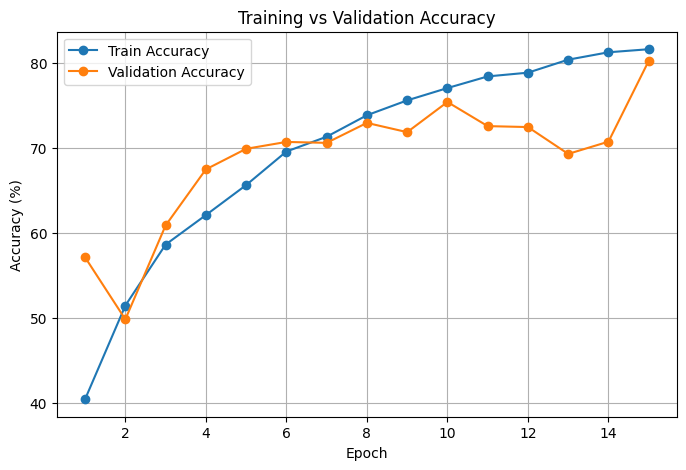

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

<h4>Loss Graph</h4>

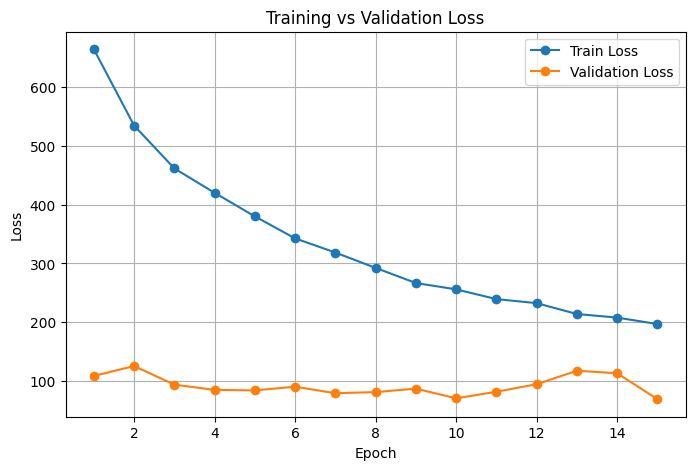

In [6]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [75]:

test_dataset = GenreDataset("processed_data/test", label_map)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [12]:
model.load_state_dict(torch.load("musicmodel.pth"))

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print("Test Accuracy:", test_acc)

C:\Users\Renish\AppData\Local\Temp\ipykernel_20984\2142348424.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("musicmodel.pth"))


Test Accuracy: 77.36047736047736


<h4>Confusion Matrix</h4>

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [14]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())

In [15]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[226   0  23   1   0  19   0   0   1  15]
 [  0 244   4   0   0  27   0   2   0   7]
 [  8   5 221   3   1  18   0   5   2  22]
 [  1   6   8 156  43   5   3  45   1  17]
 [  3   0   1  19 231   0  12   8   4   7]
 [  8   4  12   0   0 259   0   2   0   0]
 [  6   0   1   1   2   0 253   0   2  20]
 [  0   0  19   3   8   0   0 245   5   5]
 [  5   0   1  15   8   0   2  16 227  11]
 [ 11   6  37   7   1  17  14  35  15 142]]


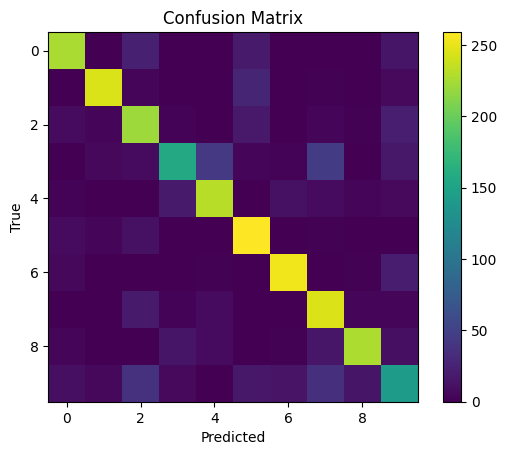

In [16]:
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [17]:
genres = [
    "blues","classical","country","disco","hiphop",
    "jazz","metal","pop","reggae","rock"
]

In [20]:
import pandas as pd 

cm_table = pd.DataFrame(cm, index=genres, columns=genres)

In [21]:
display(cm_table)

,blues,classical,country,disco,hiphop,jazz,metal,pop,reggae,rock
blues,226,0,23,1,0,19,0,0,1,15
classical,0,244,4,0,0,27,0,2,0,7
country,8,5,221,3,1,18,0,5,2,22
disco,1,6,8,156,43,5,3,45,1,17
hiphop,3,0,1,19,231,0,12,8,4,7
jazz,8,4,12,0,0,259,0,2,0,0
metal,6,0,1,1,2,0,253,0,2,20
pop,0,0,19,3,8,0,0,245,5,5
reggae,5,0,1,15,8,0,2,16,227,11
rock,11,6,37,7,1,17,14,35,15,142


<h3>Augmentation tarining</h3>

In [73]:
num_epochs = 30

best_val_acc = 0

for epoch in range(num_epochs):

    # ================= TRAINING =================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total


    # ================= VALIDATION =================
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total


    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "MusicAugModel.pth")

    # ================= PRINT RESULTS =================
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_accuracy:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/30] Train Loss: 770.3422 Train Acc: 32.27% Val Loss: 141.2497 Val Acc: 37.40%
Epoch [2/30] Train Loss: 629.3714 Train Acc: 41.56% Val Loss: 131.5044 Val Acc: 41.51%
Epoch [3/30] Train Loss: 590.1093 Train Acc: 45.16% Val Loss: 122.9695 Val Acc: 46.46%
Epoch [4/30] Train Loss: 567.0803 Train Acc: 47.05% Val Loss: 97.4180 Val Acc: 59.23%
Epoch [5/30] Train Loss: 539.8915 Train Acc: 50.15% Val Loss: 91.6378 Val Acc: 62.18%
Epoch [6/30] Train Loss: 512.3221 Train Acc: 52.31% Val Loss: 85.6956 Val Acc: 67.26%
Epoch [7/30] Train Loss: 495.7655 Train Acc: 53.90% Val Loss: 93.5539 Val Acc: 62.42%
Epoch [8/30] Train Loss: 473.9489 Train Acc: 56.22% Val Loss: 192.6381 Val Acc: 39.89%
Epoch [9/30] Train Loss: 443.9927 Train Acc: 58.63% Val Loss: 74.0590 Val Acc: 70.04%
Epoch [10/30] Train Loss: 437.1642 Train Acc: 59.28% Val Loss: 98.2997 Val Acc: 58.98%
Epoch [11/30] Train Loss: 416.6776 Train Acc: 60.50% Val Loss: 81.7413 Val Acc: 69.40%
Epoch [12/30] Train Loss: 402.5509 Train Acc: 62

In [76]:
model.load_state_dict(torch.load("MusicAugModel.pth"))

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print("Test Accuracy:", test_acc)

C:\Users\Renish\AppData\Local\Temp\ipykernel_22272\1289995031.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("MusicAugModel.pth"))


Test Accuracy: 77.22007722007721


<h3>Plot Graph Of Augmentation Training</h3>

In [7]:
train_loss_aug = [
770.3422, 629.3714, 590.1093, 567.0803, 539.8915,
512.3221, 495.7655, 473.9489, 443.9927, 437.1642,
416.6776, 402.5509, 407.2199, 385.5390, 374.5809,
369.8525, 352.3540, 334.5947, 332.0925, 320.4609,
318.4331, 295.6901, 271.9176, 253.5694, 242.7679,
224.2260, 214.3516, 195.6343, 190.3247, 172.1272
]

val_loss_aug = [
141.2497, 131.5044, 122.9695, 97.4180, 91.6378,
85.6956, 93.5539, 192.6381, 74.0590, 98.2997,
81.7413, 72.8504, 88.3149, 73.2528, 98.4658,
94.0347, 72.6354, 107.3999, 90.1820, 96.3565,
78.5392, 69.9890, 76.6047, 80.6875, 82.0795,
72.0919, 97.2262, 78.5254, 75.8024, 77.8327
]

train_acc_aug = [
32.27, 41.56, 45.16, 47.05, 50.15,
52.31, 53.90, 56.22, 58.63, 59.28,
60.50, 62.24, 61.51, 63.22, 64.77,
64.87, 66.61, 68.18, 68.17, 69.58,
69.70, 72.29, 74.50, 76.60, 77.77,
79.62, 80.13, 82.41, 82.69, 84.12
]

val_acc_aug = [
37.40, 41.51, 46.46, 59.23, 62.18,
67.26, 62.42, 39.89, 70.04, 58.98,
69.40, 71.89, 62.70, 73.26, 67.47,
66.39, 74.84, 61.16, 68.39, 69.82,
72.42, 75.54, 75.61, 72.67, 72.98,
77.40, 71.54, 75.51, 75.40, 77.79
]

<h4>Accuracy Graph</h4>

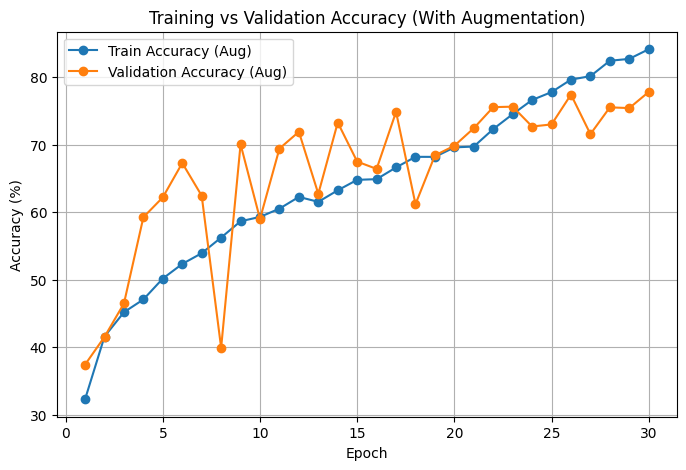

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, 31)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc_aug, marker='o', label="Train Accuracy (Aug)")
plt.plot(epochs, val_acc_aug, marker='o', label="Validation Accuracy (Aug)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (With Augmentation)")
plt.legend()
plt.grid(True)

plt.show()

<h4>Loss Graph</h4>

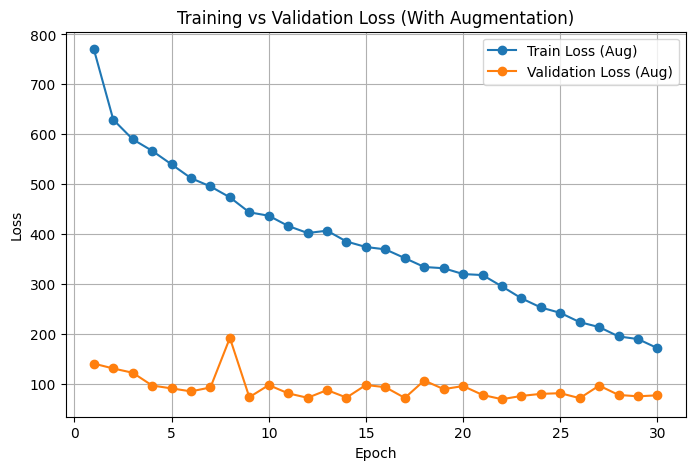

In [9]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss_aug, marker='o', label="Train Loss (Aug)")
plt.plot(epochs, val_loss_aug, marker='o', label="Validation Loss (Aug)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (With Augmentation)")
plt.legend()
plt.grid(True)

plt.show()

<h4>simple v/s Aug</h4>

In [1]:
val_acc_no_aug = [
57.16, 49.86, 60.91, 67.51, 69.93,
70.74, 70.63, 72.98, 71.89, 75.44,
72.60, 72.49, 69.33, 70.77, 80.28
]

val_acc_aug = [
37.40, 41.51, 46.46, 59.23, 62.18,
67.26, 62.42, 39.89, 70.04, 58.98,
69.40, 71.89, 62.70, 73.26, 67.47
]

<h4>Comparison Graph</h4>

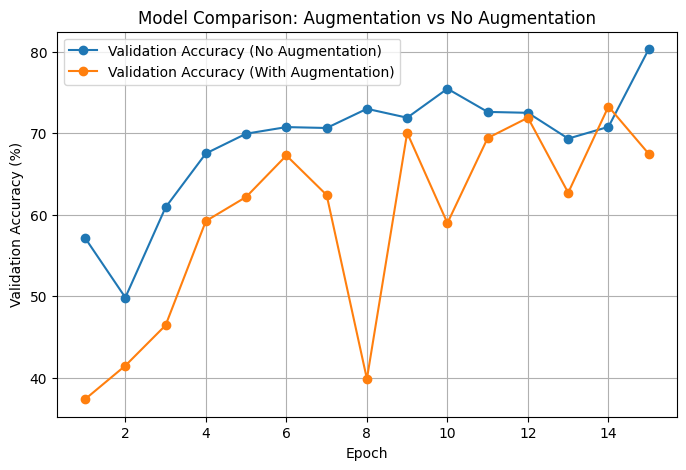

In [2]:
import matplotlib.pyplot as plt

epochs = range(1,16)

plt.figure(figsize=(8,5))

plt.plot(epochs, val_acc_no_aug, marker='o', label="Validation Accuracy (No Augmentation)")
plt.plot(epochs, val_acc_aug, marker='o', label="Validation Accuracy (With Augmentation)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Comparison: Augmentation vs No Augmentation")

plt.legend()
plt.grid(True)

plt.show()

<h4>Visulize Feature Map</h4>

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class GenreCNNVisual(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*16*16,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        f1 = x

        x = self.pool(F.relu(self.conv2(x)))
        f2 = x

        x = self.pool(F.relu(self.conv3(x)))
        f3 = x

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x, f1, f2, f3

In [5]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
import numpy as np

mel = np.load("D:\\Music_Gener_Classification\\processed_data\\test\\classical_126_99225.npy")

mel = torch.tensor(mel).float()
mel = mel.unsqueeze(0).unsqueeze(0)

mel = mel.to(device)

mel.shape

torch.Size([1, 1, 128, 130])

In [11]:
model = GenreCNNVisual().to(device=device)

model.eval()

with torch.no_grad():

    output, f1, f2, f3 = model(mel)

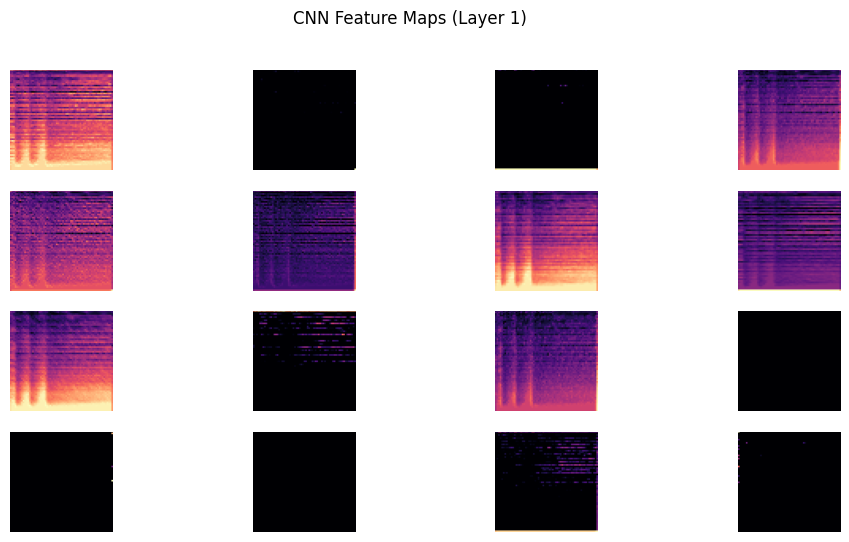

In [12]:
import matplotlib.pyplot as plt

feature_maps = f1.squeeze(0)

plt.figure(figsize=(12,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(feature_maps[i].cpu(), cmap="magma")

    plt.axis("off")

plt.suptitle("CNN Feature Maps (Layer 1)")

plt.show()